# Eye State CNN 
**Classes:** closed / open (eye level, not face level — glasses-proof)  

In [1]:
import torch
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1   = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # grayscale = 1ch
        self.conv2   = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3   = nn.Conv2d(32, 64, 3, padding=1)
        self.relu    = nn.ReLU()
        self.pool    = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)
        self.fc1     = nn.Linear(64 * 8 * 8, 128)   # 64x64 -> 8x8 after 3 pools
        self.fc2     = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Sanity check
model = CNN()
x = torch.randn(1, 1, 64, 64)   # 1 channel grayscale
print("Output shape:", model(x).shape)  # should be [1, 2]

Output shape: torch.Size([1, 2])


## 2. Transforms & DataLoaders  
Images are grayscale so normalize with `mean=[0.5] std=[0.5]` (single channel).

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

BASE = "/media/rudhratej/linux_data/projects/personal/multimodal_driver_fatigue_monitor/data/custom_eye_dataset"
train_dir = f"{BASE}/train"
val_dir   = f"{BASE}/val"

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir,   transform=train_transform)


train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_data.classes
print("Classes:", class_names)
print(f"Train: {len(train_data)} | Val: {len(val_data)} ")

Classes: ['closed', 'open']
Train: 1454 | Val: 180 


## 3. Training

In [7]:
import torch.optim as optim

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

NUM_EPOCHS = 200
best_acc   = 0.0

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    correct, total, total_loss = 0, 0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds    = torch.max(outputs, 1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    train_acc = correct / total

    
    model.eval()
    val_correct, val_total, val_loss = 0, 0, 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss      += loss.item()
            _, preds       = torch.max(outputs, 1)
            val_correct   += (preds == labels).sum().item()
            val_total     += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {total_loss:.2f}  Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "mrl_best_model.pth")
        print("  ✓ Best model saved")

print(f"\nBest val accuracy: {best_acc:.4f}")

Device: cuda
Epoch 01/200 | Train Loss: 31.81  Acc: 0.5248 | Val Acc: 0.5889
  ✓ Best model saved
Epoch 02/200 | Train Loss: 31.17  Acc: 0.6087 | Val Acc: 0.6944
  ✓ Best model saved
Epoch 03/200 | Train Loss: 29.21  Acc: 0.7001 | Val Acc: 0.4611
Epoch 04/200 | Train Loss: 25.58  Acc: 0.7263 | Val Acc: 0.5444
Epoch 05/200 | Train Loss: 22.25  Acc: 0.7737 | Val Acc: 0.6389
Epoch 06/200 | Train Loss: 19.76  Acc: 0.8116 | Val Acc: 0.6167
Epoch 07/200 | Train Loss: 17.61  Acc: 0.8315 | Val Acc: 0.6222
Epoch 08/200 | Train Loss: 15.92  Acc: 0.8597 | Val Acc: 0.6278
Epoch 09/200 | Train Loss: 13.43  Acc: 0.8817 | Val Acc: 0.7500
  ✓ Best model saved
Epoch 10/200 | Train Loss: 12.33  Acc: 0.8934 | Val Acc: 0.7611
  ✓ Best model saved
Epoch 11/200 | Train Loss: 11.35  Acc: 0.9085 | Val Acc: 0.7889
  ✓ Best model saved
Epoch 12/200 | Train Loss: 10.37  Acc: 0.9175 | Val Acc: 0.7778
Epoch 13/200 | Train Loss: 10.49  Acc: 0.9168 | Val Acc: 0.8278
  ✓ Best model saved
Epoch 14/200 | Train Loss: 9.

## 4. Test Set Evaluation

Test Accuracy: 0.7889

Classification Report:
              precision    recall  f1-score   support

      closed       0.81      0.76      0.78        90
        open       0.77      0.82      0.80        90

    accuracy                           0.79       180
   macro avg       0.79      0.79      0.79       180
weighted avg       0.79      0.79      0.79       180



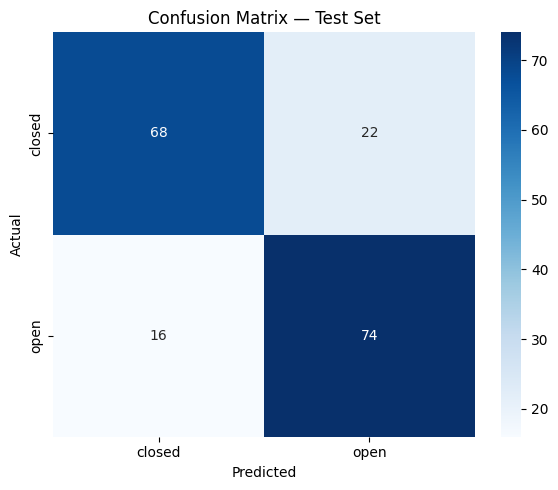

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.load_state_dict(torch.load("mrl_best_model.pth", map_location=device, weights_only=True))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"Test Accuracy: {(all_preds == all_labels).mean():.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 5. Static Image Test
Test on your own photos before hitting the webcam.

In [5]:
import cv2
from PIL import Image

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(img)
    tensor = test_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)
        _, pred = torch.max(output, 1)

    print(f"File: {img_path}")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {probs[0][i].item():.4f}")
    print(f"  → Prediction: {class_names[pred.item()]}\n")


# you can use your/anyones images for testing
#predict_image("")
#predict_image("")

## 6. Webcam Inference
MRL dataset = eye crops, so we detect face → crop eye region → classify.  
This is glasses-robust because the model learned eye features not face features.

In [6]:
import cv2
import torch
from torchvision import transforms
from PIL import Image
from collections import deque
import numpy as np

model.load_state_dict(torch.load("mrl_best_model.pth", map_location=device, weights_only=True))
model.eval()

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


infer_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("Class map:", train_data.class_to_idx)
CLOSED_IDX   = train_data.class_to_idx.get('closed', 0)
OPEN_IDX     = 1 - CLOSED_IDX
LABEL_COLORS = {"closed": (0, 0, 255), "open": (0, 255, 0)}

prob_buffer = deque(maxlen=8)

def run_inference(frame):
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3, minSize=(60, 60))

    for (x, y, w, h) in faces[:1]:
        # Eye strip: 25-45% of face height, skip temples
        ey1 = int(h * 0.30)
        ey2 = int(h * 0.52)
        ex1 = int(w * 0.08)
        ex2 = int(w * 0.92)

        abs_x1 = max(x + ex1, 0)
        abs_y1 = max(y + ey1, 0)
        abs_x2 = min(x + ex2, frame.shape[1])
        abs_y2 = min(y + ey2, frame.shape[0])

        eye_crop = frame[abs_y1:abs_y2, abs_x1:abs_x2]

        if eye_crop.size == 0 or eye_crop.shape[0] < 10 or eye_crop.shape[1] < 10:
            continue

        eye_pil    = Image.fromarray(cv2.cvtColor(eye_crop, cv2.COLOR_BGR2RGB))
        eye_tensor = infer_transform(eye_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            probs = torch.softmax(model(eye_tensor), dim=1).cpu().numpy()[0]

        prob_buffer.append(probs)
        smoothed   = np.mean(prob_buffer, axis=0)
        CLOSED_THRESHOLD = 0.35
        closed_prob = smoothed[CLOSED_IDX]

        if closed_prob > CLOSED_THRESHOLD:
            label = class_names[CLOSED_IDX]
            conf  = closed_prob
            color = (0, 0, 255)
        else:
            label = class_names[OPEN_IDX]
            conf  = smoothed[OPEN_IDX]
            color = (0, 255, 0)

        # Draw face box
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 200, 0), 1)
        # Draw eye crop box
        cv2.rectangle(frame, (abs_x1, abs_y1), (abs_x2, abs_y2), color, 2)
        cv2.putText(frame, f"{label} {conf:.2f}",
                    (abs_x1, abs_y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    return frame


cap = cv2.VideoCapture(1)

if not cap.isOpened():
    print("Error: Cannot open webcam")
else:
    print("Running — press Q to quit")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow("Eye State Detection", run_inference(frame))
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

Class map: {'closed': 0, 'open': 1}
Error: Cannot open webcam


[ WARN:0@0.071] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ERROR:0@0.072] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
